In [1]:
import os
import numpy as np
import tensorflow as tf
import keras
from keras import layers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt

In [2]:
directory = "Images"

num_skipped = 0
for folder_name in os.listdir(directory):
    folder_path = os.path.join(directory, folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        finally:
            fobj.close()
        
        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)

print(f"Deleted {num_skipped} images.")

Deleted 0 images.


In [3]:
image_size = (180, 180)
batch_size = 32

full_train_ds, full_val_ds = keras.utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True
)

# How large (%) is the subset 
subset_ratio = 1

num_train_batches = int(len(full_train_ds) * subset_ratio)
num_val_batches = int(len(full_val_ds) * subset_ratio)

train_ds = full_train_ds.take(num_train_batches)
val_ds = full_val_ds.take(num_val_batches)

Found 20569 files belonging to 120 classes.
Using 16456 files for training.
Using 4113 files for validation.


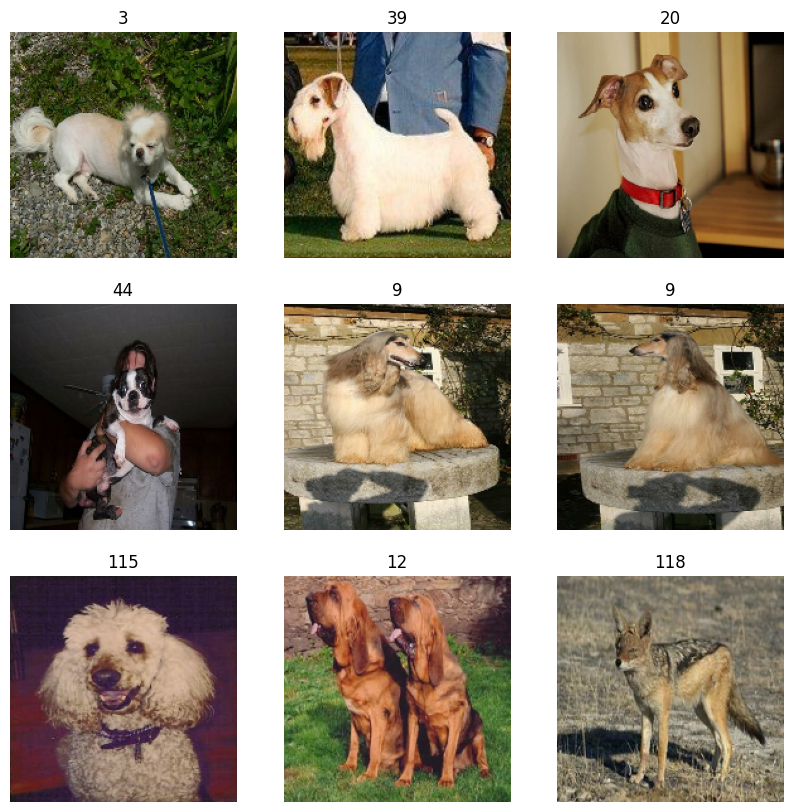

In [4]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

In [5]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1)
]


def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

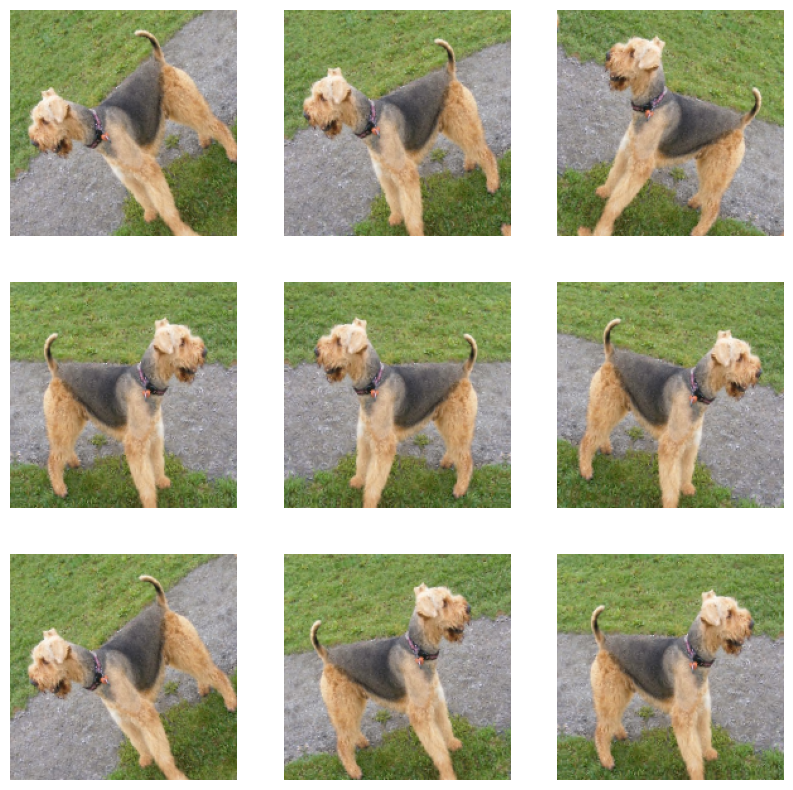

In [6]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

In [7]:
augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

In [8]:
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label),
    num_parallel_calls=tf_data.AUTOTUNE
)

train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)

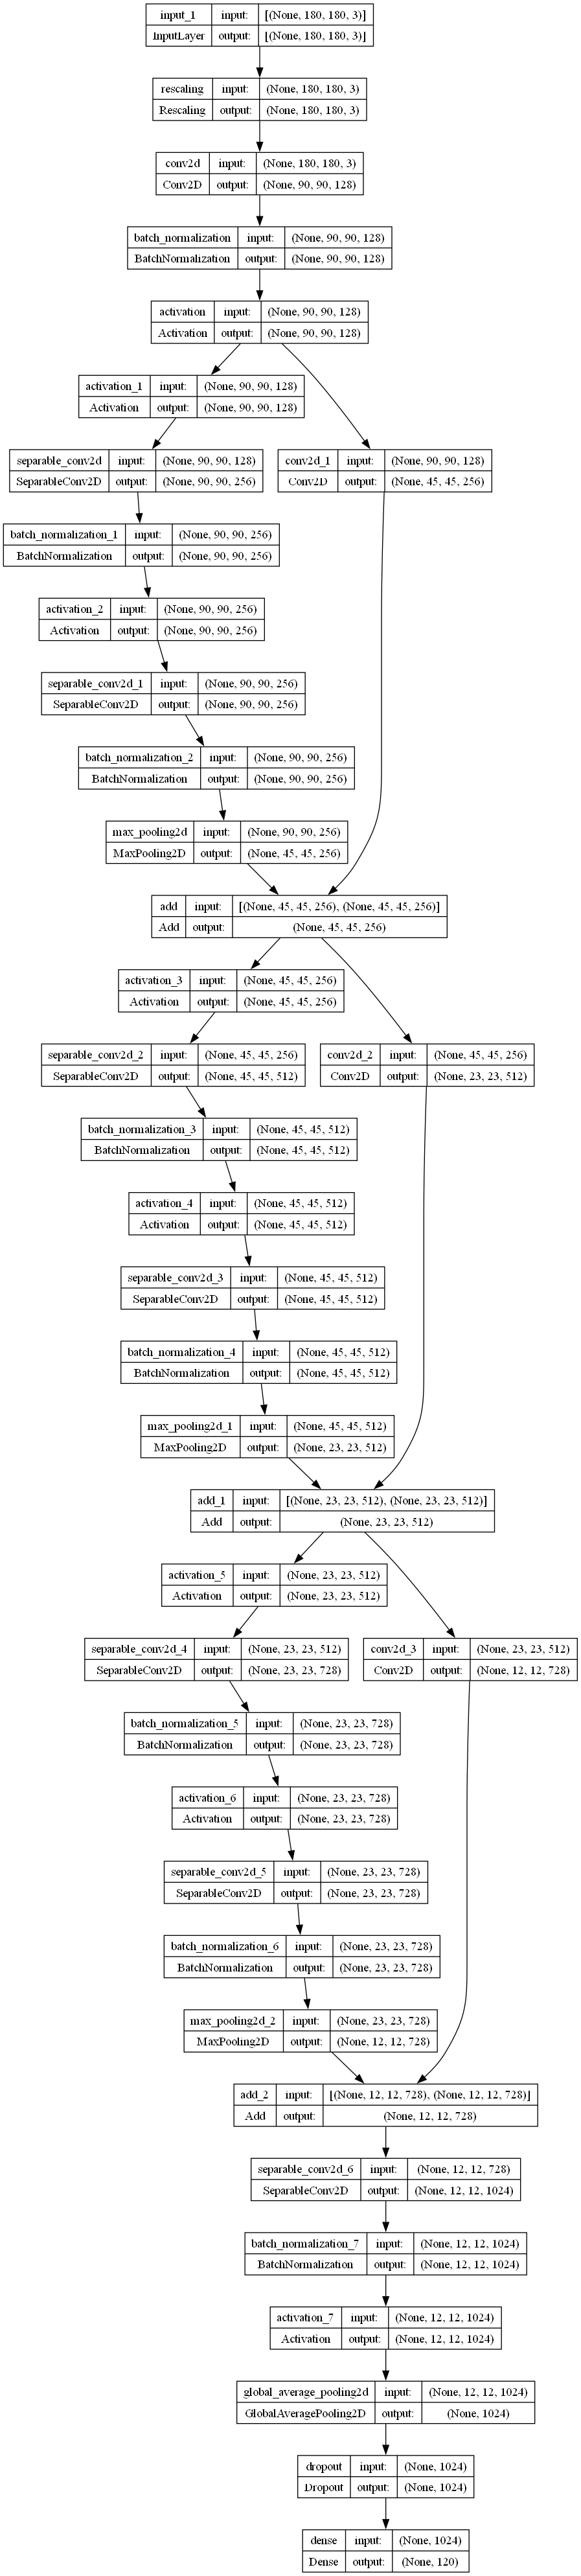

In [9]:
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # Entry block
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x # Set aside residual

    for size in [256, 512, 728]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])
        previous_block_activation = x
    
    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        units = 1
    else:
        units = num_classes

    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(units, activation=None)(x)
    return keras.Model(inputs, outputs)


model = make_model(input_shape=image_size + (3,), num_classes=120)
keras.utils.plot_model(model, show_shapes=True)

In [10]:
epochs = 25

callbacks = [
    keras.callbacks.ModelCheckpoint("Stanford_dog/save_at_{epoch}.keras")
]

model.compile(
    optimizer=keras.optimizers.Adam(0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds
)

Epoch 1/25
515/515 [==============================] - 79s 144ms/step - loss: 4.6723 - accuracy: 0.0284 - val_loss: 4.8674 - val_accuracy: 0.0119
Epoch 2/25
515/515 [==============================] - 61s 119ms/step - loss: 4.3860 - accuracy: 0.0542 - val_loss: 4.4057 - val_accuracy: 0.0518
Epoch 3/25
515/515 [==============================] - 60s 116ms/step - loss: 4.1608 - accuracy: 0.0770 - val_loss: 4.2826 - val_accuracy: 0.0525
Epoch 4/25
515/515 [==============================] - 60s 116ms/step - loss: 3.9474 - accuracy: 0.1053 - val_loss: 4.0930 - val_accuracy: 0.0780
Epoch 5/25
515/515 [==============================] - 60s 117ms/step - loss: 3.7527 - accuracy: 0.1355 - val_loss: 4.0828 - val_accuracy: 0.0773
Epoch 6/25
515/515 [==============================] - 80s 155ms/step - loss: 3.5858 - accuracy: 0.1604 - val_loss: 3.9077 - val_accuracy: 0.0977
Epoch 7/25
515/515 [==============================] - 61s 119ms/step - loss: 3.4364 - accuracy: 0.1824 - val_loss: 3.7063 - val_ac

In [12]:
model_path = "stanford_dog_model.h5"
model.save(model_path)

In [13]:
model = tf.keras.models.load_model(model_path)

callbacks = [
    keras.callbacks.ModelCheckpoint("Stanford_dog/save_at_{epoch}.keras")
]

model.fit(
    train_ds,
    epochs=25,
    callbacks=callbacks,
    validation_data=val_ds
)

Epoch 1/25
515/515 [==============================] - 59s 113ms/step - loss: 0.7288 - accuracy: 0.8038 - val_loss: 3.9437 - val_accuracy: 0.2339
Epoch 2/25
515/515 [==============================] - 59s 114ms/step - loss: 0.6865 - accuracy: 0.8188 - val_loss: 4.1485 - val_accuracy: 0.2227
Epoch 3/25
515/515 [==============================] - 58s 112ms/step - loss: 0.6683 - accuracy: 0.8207 - val_loss: 3.9964 - val_accuracy: 0.2232
Epoch 4/25
515/515 [==============================] - 58s 113ms/step - loss: 0.6550 - accuracy: 0.8229 - val_loss: 3.8965 - val_accuracy: 0.2536
Epoch 5/25
515/515 [==============================] - 58s 112ms/step - loss: 0.6154 - accuracy: 0.8384 - val_loss: 3.7031 - val_accuracy: 0.2619
Epoch 6/25
515/515 [==============================] - 58s 112ms/step - loss: 0.6185 - accuracy: 0.8359 - val_loss: 4.0368 - val_accuracy: 0.2283
Epoch 7/25
515/515 [==============================] - 58s 112ms/step - loss: 0.5755 - accuracy: 0.8508 - val_loss: 3.7810 - val_ac

In [14]:
model.evaluate(
    val_ds
)

129/129 [==============================] - 4s 25ms/step - loss: 4.5815 - accuracy: 0.2237


[4.581501483917236, 0.2236810177564621]